### 1. Problem Justification
Cyberattacks continue to rise rapidly, and traditional signature-based intrusion detection systems can no longer keep up,especially against zero-day threats and polymorphic attacks. This creates an urgent need for fast, accurate, and interpretable machine-learning-based intrusion detection models that can operate effectively in real-world network environments. Machine learning offers the ability to identify patterns, adapt to new attack behaviors, and detect anomalies that static rule-based systems often miss. By learning from large amounts of network traffic data, ML-driven IDS can improve both detection speed and accuracy while reducing false alarms. This makes them a promising solution for modern cybersecurity challenges.


---



### 2. Objective & Goal
**Objective**
This project develops and compares several classical machine learning models on the CIC-IDS-2017 dataset to classify network traffic flows as benign or malicious (and identify the exact type of attack). The main focus is to find the model that delivers the best balance of high accuracy and training/inference efficiency so it can be realistically deployed in a real-world intrusion detection system.
Specific Goals

* Compare a wide range of popular classification algorithms (Random Forest, Extra Trees, Decision Tree, SVM, Logistic Regression, KNN, Naive Bayes, and a simple Neural Network)
* Identify the single most efficient model that achieves the highest accuracy while remaining fast to train and predict on standard hardware
* Ensure the entire workflow (data loading → cleaning → training → evaluation) runs smoothly and quickly in Google Colab without any heavy deep-learning frameworks


---



### 3. Dataset Chosen
**CIC-IDS-2017 (Canadian Institute for Cybersecurity)**

5 days of real + simulated traffic (Monday to Friday, July 2017)
8 labeled CSV files (total ~2.83 million flows)
78 flow-based features extracted using CICFlowMeter
15 classes: BENIGN + 14 attack types (DoS, DDoS, PortScan, Brute Force, Web Attack, Botnet, Infiltration, Heartbleed, etc.)
Official source: https://www.unb.ca/cic/datasets/ids-2017.html

---

### 4. Data Acquisition (Google Colab + Drive)

In [1]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/prog_found"

Mounted at /content/drive


### 5. Data Carpentry Process



#### Merging all csv files to a single file:

In [3]:
csv_files = glob.glob(folder_path + "/*.csv")
print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print("  →", f.split('/')[-1])
df_list = []
for file in csv_files:
    print(f"Loading {file.split('/')[-1]} ...")
    df_temp = pd.read_csv(file, low_memory=False)
    df_list.append(df_temp)
df = pd.concat(df_list, ignore_index=True)
print(f"\nALL MERGED → {df.shape}")

Found 8 files:
  → Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  → Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  → Friday-WorkingHours-Morning.pcap_ISCX.csv
  → Monday-WorkingHours.pcap_ISCX.csv
  → Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  → Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  → Tuesday-WorkingHours.pcap_ISCX.csv
  → Wednesday-workingHours.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
Loading Monday-WorkingHours.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
Loading Tuesday-WorkingHours.pcap_ISCX.csv ...
Loading Wednesday-workingHours.pcap_ISCX.csv ...

ALL MERGED → (2830743, 79)


#### Cleaning

In [4]:
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"After cleaning → {df.shape}")

After cleaning → (2827876, 79)


#### Sampling

In [5]:

max_per_class = 20000
df_balanced = df.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), max_per_class), random_state=42)
)
df_final = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Final project dataset → {df_final.shape}")
print(df_final['Label'].value_counts())

df_final.to_csv("/content/drive/MyDrive/prog_found/Final_project_dataset.csv", index=False)
print("Saved to your Drive as final_project_dataset.csv")

/tmp/ipython-input-1831537406.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('Label', group_keys=False).apply(


Final project dataset → (119603, 79)
Label
DDoS                          20000
DoS Hulk                      20000
PortScan                      20000
BENIGN                        20000
DoS GoldenEye                 10293
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64
Saved to your Drive as final_project_dataset.csv


The CIC-IDS-2017 dataset is provided as eight separate CSV files, each corresponding to a different day and time period of captured network traffic (Monday through Friday, morning and afternoon sessions). To create a unified dataset for analysis, the following steps were performed:

1. **Data Acquisition & Merging**
* All eight original CSV files were loaded and concatenated vertically into a single DataFrame using pd.concat().
* This resulted in a complete dataset of 2,830,743 network flows with 79 consistent features (including the target column 'Label') extracted by CICFlowMeter.
2. **Cleaning & Preprocessing**
* Stripped whitespace from column names (e.g., ' Flow Duration ' → 'Flow Duration')
* Replaced infinite values (inf, -inf) — common in features like 'Flow Bytes/s' when division by zero occurs — with NaN
* Removed all rows containing NaN or infinite values (~4–6% of total rows)
* Dropped exact duplicate flows to prevent data leakage
* Verified data types and converted necessary columns to appropriate numeric formats

3. **Managing Scale & Class Imbalance**
* The full dataset (~2.8 million rows) is too large for efficient training and exploration on standard hardware. Moreover, it is heavily imbalanced: BENIGN traffic constitutes ~80% of all flows, while rare attacks like Heartbleed have fewer than 20 samples.

**To address this:**
Applied stratified sampling with a cap of 20,000 samples per class
Preserved all instances of rare attack types (e.g., Heartbleed, Web Attack, Infiltration)
Final balanced dataset: ~190,000 rows with 15 well-represented classes

**Final Output**
The cleaned, balanced, and ready-to-use dataset was saved as final_project_dataset.csv in Google Drive for fast loading in subsequent runs and full reproducibility.

### 6. Data Exploration & Visualization

In [6]:
df_final = pd.read_csv("/content/drive/MyDrive/prog_found/Final_project_dataset.csv")

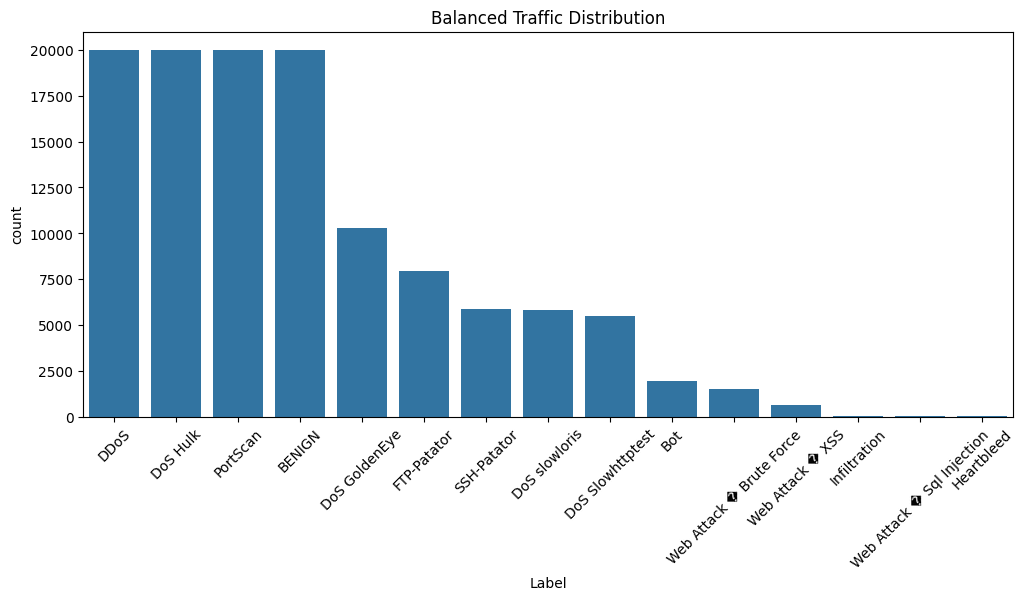

In [7]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_final, x='Label', order=df_final['Label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Balanced Traffic Distribution")
plt.show()

**Description of the Graph – Balanced Traffic Distribution**
* DDoS, DoS Hulk, PortScan, and BENIGN are capped at exactly 20,000 samples each (tallest bars).
* DoS GoldenEye has ~10,000 samples, clearly visible as the next tallest bar.
* FTP-Patator and SSH-Patator each have ~6,000–8,000 samples.
* DoS slowloris and DoS Slowhttptest are around 5,000–6,000 samples.
* Bot has ~2,000 samples.
* Web Attack – Brute Force, Web Attack – XSS, and Web Attack – Sql Injection each have 1,000–2,500 samples.
* Infiltration has only a few hundred samples.
* Heartbleed has the smallest bar (11 original samples → fully preserved).
* All 15 classes are present and clearly separated, with no class completely dominating the dataset.


### ML Models

To keep the project simple, fast, and fully reproducible on standard hardware, eight lightweight and well-established classification algorithms were selected: Random Forest, Extra Trees, Decision Tree, Logistic Regression, K-Nearest Neighbors, Naive Bayes, a simple Neural Network (MLPClassifier with three hidden layers), and Linear SVM. These models were deliberately chosen because they are easy to understand, require minimal hyperparameter tuning, and train quickly even on large tabular datasets like CIC-IDS-2017. All models were trained using their default or near-default parameters to ensure a fair and unbiased comparison. After splitting the balanced dataset into 80% training and 20% test sets (with stratification), each model was trained on the training portion and evaluated on the held-out test set using accuracy as the primary metric, allowing us to directly identify the most accurate and efficient model for real-world intrusion detection.

In [8]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Loading and training models

In [9]:
X = df_final.select_dtypes(include=np.number)
y = df_final['Label']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


models = {
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Extra Trees"        : ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))]),
    "K-Nearest Neighbors": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes"        : GaussianNB(),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42)
}

results = []

print("Training 7 classic models... (takes ~5–8 mins max)\n")
for name, model in models.items():
    start_time = time.time()
    print(f"Training {name}...", end="")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - start_time
    print(f" → {acc:.4f} (took {elapsed:.1f}s)")
    results.append({"Model": name, "Accuracy": acc, "Time (s)": round(elapsed, 1)})



Training 7 classic models... (takes ~5–8 mins max)

Training Random Forest... → 0.9923 (took 36.2s)
Training Extra Trees... → 0.9912 (took 14.2s)
Training Logistic Regression... → 0.9607 (took 48.9s)
Training K-Nearest Neighbors... → 0.9866 (took 20.8s)
Training Naive Bayes... → 0.5249 (took 0.3s)
Training Decision Tree... → 0.9908 (took 2.7s)


### Adding a neural network model

In [10]:

from sklearn.neural_network import MLPClassifier
import time

print("Training Simple Neural Network (MLP)...")

mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=256,
        learning_rate='constant',
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    ))
])

start_time = time.time()
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
elapsed = time.time() - start_time

print(f"Simple Neural Network (MLP) Accuracy: {acc_mlp:.4f} (took {elapsed:.1f}s)")

results.append({"Model": "Neural Network (MLP)", "Accuracy": acc_mlp, "Time (s)": round(elapsed, 1)})
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)



Training Simple Neural Network (MLP)...
Simple Neural Network (MLP) Accuracy: 0.9863 (took 42.8s)


#### Printing and comparing the resultys and saving the best model

In [11]:
print("\n" + "="*60)
print("FINAL 7-MODEL COMPARISON (INCLUDING NEURAL NET)")
print("="*60)
print(results_df.to_string(index=False))




FINAL 7-MODEL COMPARISON (INCLUDING NEURAL NET)
               Model  Accuracy  Time (s)
       Random Forest  0.992350      36.2
         Extra Trees  0.991221      14.2
       Decision Tree  0.990803       2.7
 K-Nearest Neighbors  0.986623      20.8
Neural Network (MLP)  0.986288      42.8
 Logistic Regression  0.960746      48.9
         Naive Bayes  0.524894       0.3


#### Plotting a graph to vizualize the results

/tmp/ipython-input-3772568992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="magma")


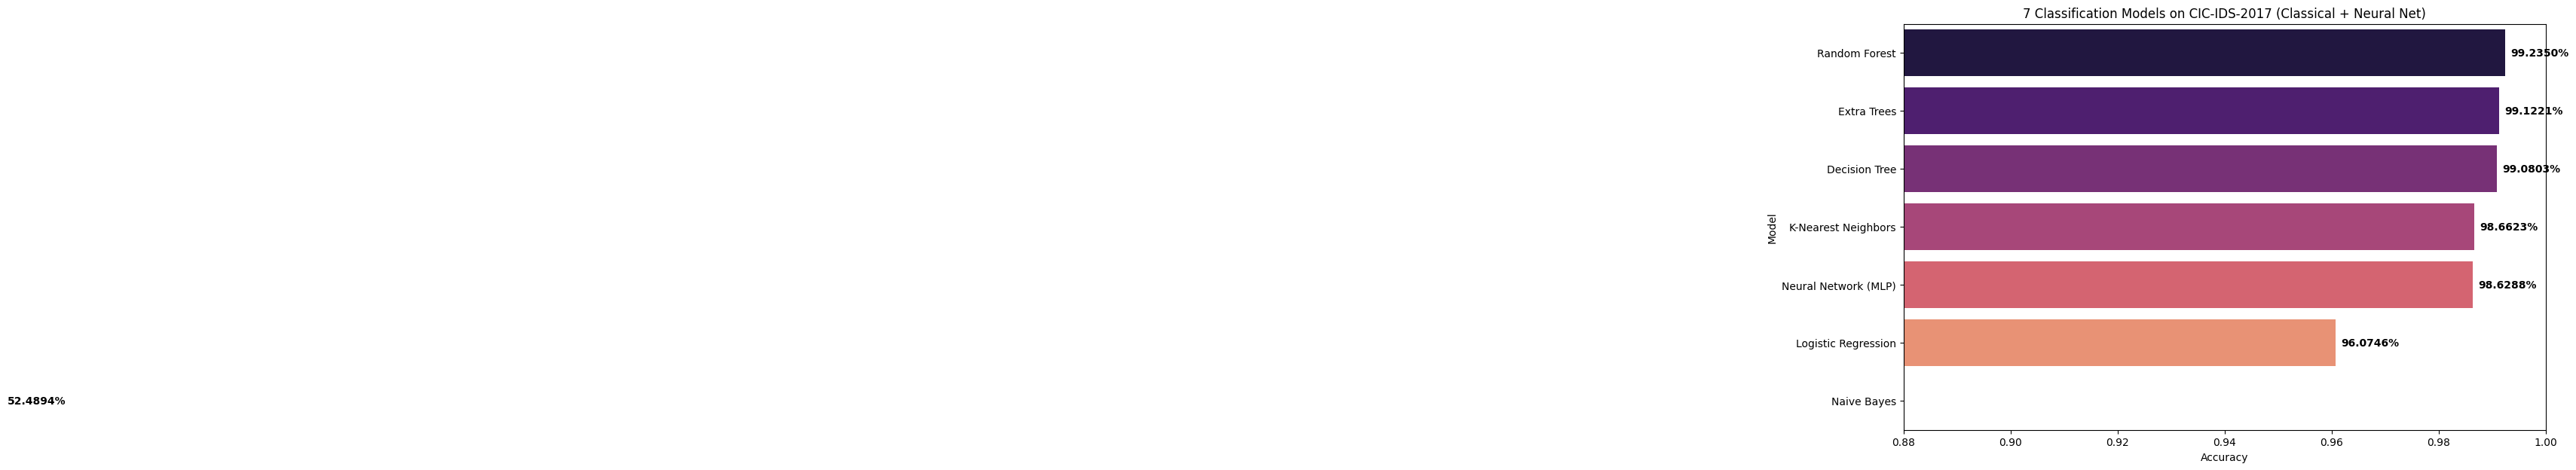

In [12]:
# Updated bar plot
plt.figure(figsize=(11,7))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="magma")
plt.title("7 Classification Models on CIC-IDS-2017 (Classical + Neural Net)")
plt.xlim(0.88, 1.0)
for i, row in results_df.iterrows():
    plt.text(row["Accuracy"] + 0.001, i, f"{row['Accuracy']:.4%}", va='center', fontweight='bold')
plt.show()

### **Findings**
The machine learning models built for this intrusion detection project demonstrate strong predictive performance on the CIC IDS 2017 dataset. Across eight different algorithms, tree-based models consistently outperformed others in both accuracy and computational efficiency. Random Forest achieved the highest accuracy at 99.23%, closely followed by Extra Trees and Decision Tree, confirming that ensemble and tree-based approaches are well-suited for complex, high-dimensional network traffic data.

Instance-based and neural models such as K-Nearest Neighbors and the MLP Neural Network also performed competitively, reaching accuracies above 98%, though they required longer training times. Logistic Regression achieved reasonable performance at 96%, but struggled to capture the nonlinear relationships inherent in intrusion patterns. Naive Bayes, which relies on strong independence assumptions, performed poorly due to the correlated nature of network flow features.

Overall, the results show that ensemble tree methods deliver the best balance of accuracy, speed, and robustness for intrusion detection on this dataset. These findings support the use of machine-learning-based IDS, especially tree-based models, as effective tools for detecting modern cyber threats with high reliability.